BUSINESS UNDERSTANDING

Objective

This project aims to create a machine learning model which detects clinical parameters that are most significant in predicting/detecting diabetes.

Key Questions 

1. Which parameter is the highest predictor of diabetes?

2. Which parameter is the lowest predictor of diabetes?

3. Which 2 parameters combined are likely to result in diabetes?

4. Which parameter is strongly correlated with diabetes outcome?

KEY STAKEHOLDERS

1.Physicians 

Responsible for screening, diagnosing and managing patients.

2.Nutritionists

Responsible for providing dietary advise to patients especially those having obesity

3.Public health professionals

Responsible for creating awareness on non communicable diseases like diabetes.

DATA UNDERSTANDING

The dataset used was obtained from Kaggle.

It contains data of female patients aged atleast 21yrs and of Pima Indian origin.

It contains 768 rows and 9 columns.

The column names of the dataset represent the following:

*Pregnancies: Number of times pregnant

*Glucose: Plasma glucose concentration a 2 hours in an oral glucose tolerance test

*BloodPressure: Diastolic blood pressure (mm Hg)

*SkinThickness: Triceps skin fold thickness (mm)

*Insulin: 2-Hour serum insulin (mu U/ml)

*BMI: Body mass index (weight in kg/(height in m)^2)

*DiabetesPedigreeFunction: Diabetes pedigree function

*Age: Age (years)

*Outcome: Class variable (0- No diabetes or 1-Diabetes)

This machine learning model:
  Has high recall to reduce missed diagnosis of diabetes.



In [830]:
#Importing necessary libraries
import pandas as pd
import numpy as np 
import seaborn as sns
import sqlite3
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV,cross_validate, cross_val_predict, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.utils import resample
from sklearn.metrics import accuracy_score,precision_score, recall_score, confusion_matrix

In [831]:
#Load the dataset
data=pd.read_csv("diabetes.csv")


In [832]:
#checking the number of rows and columns
print(data.shape)

(768, 9)


This dataset contains 768 rows and 9 columns

In [833]:
#checking a preview of the first 5 rows
data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [834]:
#checking the data types of the columns in the dataset
print(data.dtypes)

Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object


In [835]:
#check a summary statistic of the columns
print(data.describe())

       Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
count   768.000000  768.000000     768.000000     768.000000  768.000000   
mean      3.845052  120.894531      69.105469      20.536458   79.799479   
std       3.369578   31.972618      19.355807      15.952218  115.244002   
min       0.000000    0.000000       0.000000       0.000000    0.000000   
25%       1.000000   99.000000      62.000000       0.000000    0.000000   
50%       3.000000  117.000000      72.000000      23.000000   30.500000   
75%       6.000000  140.250000      80.000000      32.000000  127.250000   
max      17.000000  199.000000     122.000000      99.000000  846.000000   

              BMI  DiabetesPedigreeFunction         Age     Outcome  
count  768.000000                768.000000  768.000000  768.000000  
mean    31.992578                  0.471876   33.240885    0.348958  
std      7.884160                  0.331329   11.760232    0.476951  
min      0.000000                  

In [836]:
# checking to see the most common age of the patients used in the dataset
mode_age= data["Age"].mode()
mode_age

0    22
dtype: int64

In [837]:
# checking for missing values in any of the columns
print(data.isnull().any())

Pregnancies                 False
Glucose                     False
BloodPressure               False
SkinThickness               False
Insulin                     False
BMI                         False
DiabetesPedigreeFunction    False
Age                         False
Outcome                     False
dtype: bool


No missing values were found in any of the columns.

In [838]:
#checking for duplicates
print(data.duplicated().sum())

0


No duplicates were found in the data

It is not physiologically possible to have zero values in the Glucose, BMI , BloodPressure, insulin and SkinThickness columns. Any zero values in those columns will therefore be treated as missing values.

In [839]:
#Checking if the Glucose, BMI , BloodPressure, insulin and SkinThickness columns have values of 0.
zero_values= (data[['Glucose', 'Insulin', 'SkinThickness','BloodPressure', 'BMI']] == 0).sum()
print(zero_values)

Glucose            5
Insulin          374
SkinThickness    227
BloodPressure     35
BMI               11
dtype: int64


A total of 5,374,227,35,11 zero values were found in the Glucose,Insulin, SkinThickness, BloodPressure and BMI columns respectively.

In [840]:
# Replacing 0 with NaN in the columns below with the assumption that they're missing values.
columns = ['Glucose', 'Insulin', 'SkinThickness', 'BloodPressure','BMI']
data[columns] = data[columns].replace(0, np.nan)

In [841]:
# Replacing NaN values with the mean of their respective columns
data[columns] = data[columns].apply(lambda x: x.fillna(x.mean()))

In [842]:
#confirming if the zero values were correctly replaced
zero_values = (data[['Glucose', 'Insulin','BloodPressure','SkinThickness', 'BMI']] == 0).sum()
print(zero_values)

Glucose          0
Insulin          0
BloodPressure    0
SkinThickness    0
BMI              0
dtype: int64


In [843]:
#checking for class imbalance
data['Outcome'].value_counts(normalize=True)

0    0.651042
1    0.348958
Name: Outcome, dtype: float64

The dataset is slightly imbalanced which means that any model created out of it to detect diabetic patients will be biased on the majority patients. Balancing this dataset will improve detection and improve recall.

In [844]:
#upsampling 
data_most = data[data['Outcome'] == 0]
data_least = data[data['Outcome'] == 1]

data_least_upsampled = resample(
    data_least,
    replace=True,
    n_samples=len(data_most),
    random_state=42
)

data_balanced = pd.concat([data_most, data_least_upsampled])

In [845]:
# comparing the balanced and imbalanced results
# with class imbalance
print("Original:")
print(data['Outcome'].value_counts(normalize=True))

# After handling class imbalance
print("\nBalanced:")
print(data_balanced['Outcome'].value_counts(normalize=True))

Original:
0    0.651042
1    0.348958
Name: Outcome, dtype: float64

Balanced:
1    0.5
0    0.5
Name: Outcome, dtype: float64


In [846]:
#creating an SQL table
conn=sqlite3.connect('diabetes.data')
data.to_sql('diabetes', conn, if_exists='replace', index=False)

In [847]:
#checking if the SQL table actually exists
query = "SELECT * FROM diabetes LIMIT 5;"
result = pd.read_sql(query, conn)

print(result)

   Pregnancies  Glucose  BloodPressure  SkinThickness     Insulin   BMI  \
0            6    148.0           72.0       35.00000  155.548223  33.6   
1            1     85.0           66.0       29.00000  155.548223  26.6   
2            8    183.0           64.0       29.15342  155.548223  23.3   
3            1     89.0           66.0       23.00000   94.000000  28.1   
4            0    137.0           40.0       35.00000  168.000000  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  


In [848]:
pd.read_sql(""" SELECT BMI, Glucose,DiabetesPedigreeFunction, BloodPressure FROM diabetes WHERE Glucose >139  and Outcome = 1 and BMI >=25;""",conn)

,BMI,Glucose,DiabetesPedigreeFunction,BloodPressure
0,33.6,148.0,0.627,72.0
1,30.5,197.0,0.158,70.0
2,38.0,168.0,0.537,74.0
3,30.1,189.0,0.398,60.0
4,25.8,166.0,0.587,72.0
...,...,...,...,...
125,36.4,187.0,0.408,70.0
126,43.3,181.0,0.222,88.0
127,32.4,154.0,0.443,78.0
128,35.5,190.0,0.278,92.0


The above cell shows that there is a 16.92% probability  of a patient being diagnosed with diabetes if their BMI is >=25 and 2h plasma glucose on OGTT >139.

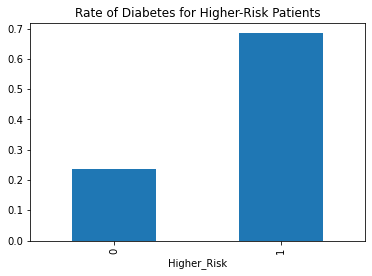

In [849]:
data['Higher_Risk'] = ((data['Glucose'] >= 139) & (data['BMI'] >= 25)).astype(int)

data.groupby('Higher_Risk')['Outcome'].mean().plot(kind='bar')
plt.title('Rate of Diabetes for Higher-Risk Patients')
plt.show()

The above bar chart shows that patients with high levels of glucose and BMI>25 are at a higher risk of having diabetes as compared to having either parameters singly.

In [850]:
#log transformation of the glucose column to prevent skewness of the data
data['Glucose_log'] = np.log(data['Glucose'] + 1)

In [851]:
X = data.drop('Outcome', axis=1)
y = data['Outcome']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [852]:
model1 = LogisticRegression(max_iter=1000)
model1.fit(X_train, y_train)

y_pred = model1.predict(X_test)

In [853]:
# With class weights
model2 = LogisticRegression(max_iter=1000, class_weight='balanced')
model2.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [854]:
y_pred1 = model1.predict(X_test)
y_pred2 = model2.predict(X_test)

In [855]:
from sklearn.metrics import classification_report, roc_auc_score

print("Default Model")
print(classification_report(y_test, y_pred1))

print("Balanced Model")
print(classification_report(y_test, y_pred2))

Default Model
              precision    recall  f1-score   support

           0       0.81      0.82      0.81        99
           1       0.67      0.65      0.66        55

    accuracy                           0.76       154
   macro avg       0.74      0.74      0.74       154
weighted avg       0.76      0.76      0.76       154

Balanced Model
              precision    recall  f1-score   support

           0       0.82      0.69      0.75        99
           1       0.56      0.73      0.63        55

    accuracy                           0.70       154
   macro avg       0.69      0.71      0.69       154
weighted avg       0.73      0.70      0.71       154



In [856]:
results = {
    'Model': ['Default Logistic', 'Balanced Logistic'],
    'ROC_AUC': [
        roc_auc_score(y_test, model1.predict_proba(X_test)[:,1]),
        roc_auc_score(y_test, model2.predict_proba(X_test)[:,1])
    ]
}

import pandas as pd
comparison = pd.DataFrame(results)
comparison

,Model,ROC_AUC
0,Default Logistic,0.824793
1,Balanced Logistic,0.822590


Does balancing actually improve recall which translates to better detection of diabetic patients?Below I'll compare the recall_score of the 2 models:the one that utilized the balanced dataset and the one that used the imbalanced dataset.

The ROC_AUC score of 0.822 shows that the model is performing well.

In [857]:
comparison['Recall'] = [recall_score(y_test, y_pred1),recall_score(y_test, y_pred2)]
comparison

,Model,ROC_AUC,Recall
0,Default Logistic,0.824793,0.654545
1,Balanced Logistic,0.822590,0.727273


The above results show that the model using the balanced dataset had a better recall_score. This is important clinically as the incidence of  missed diagnosis will be less,which means early detection,treatment and care for diabetic patients.

In [858]:
from sklearn.tree import DecisionTreeClassifier

tree = DecisionTreeClassifier(max_depth=4)
tree.fit(X_train, y_train)

y_pred_tree = tree.predict(X_test)

In [859]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Accuracy
accuracy = accuracy_score(y_test, y_pred_tree)
print("Accuracy:", accuracy)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_tree)
print("Confusion Matrix:\n", cm)

# Detailed metrics
print(classification_report(y_test, y_pred_tree))

Accuracy: 0.7142857142857143
Confusion Matrix:
 [[70 29]
 [15 40]]
              precision    recall  f1-score   support

           0       0.82      0.71      0.76        99
           1       0.58      0.73      0.65        55

    accuracy                           0.71       154
   macro avg       0.70      0.72      0.70       154
weighted avg       0.74      0.71      0.72       154



In [860]:
# Checking which features are of great importance when detecting diabetes.

# 1️⃣ Feature Importance
feature_importances = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': tree.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("Feature Importances:\n", feature_importances)



Feature Importances:
                     Feature  Importance
9               Glucose_log    0.526053
5                       BMI    0.231348
7                       Age    0.146613
1                   Glucose    0.048658
4                   Insulin    0.031825
6  DiabetesPedigreeFunction    0.015502
0               Pregnancies    0.000000
2             BloodPressure    0.000000
3             SkinThickness    0.000000
8               Higher_Risk    0.000000


The findings show that glucose is the highest predictor of diabetes while SkinThickness is the least predictor.

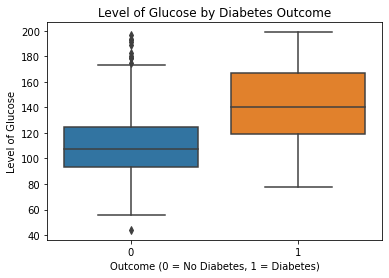

In [861]:
sns.boxplot(x='Outcome', y='Glucose', data=data)
plt.title('Level of Glucose by Diabetes Outcome')
plt.ylabel('Level of Glucose')
plt.xlabel('Outcome (0 = No Diabetes, 1 = Diabetes)')
plt.show()

As per the box plot above,Glucose levels is a key diagnostic feature for diabetes as most dabetic patients usually have high glucose levels

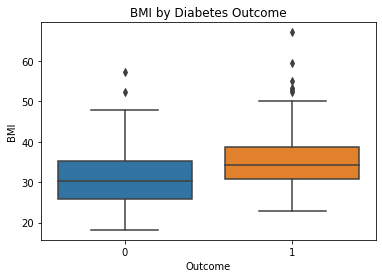

In [862]:
sns.boxplot(x='Outcome', y='BMI', data=data)
plt.title('BMI by Diabetes Outcome')
plt.show()

Obesity is a  major risk factor for diabetes as observed in the above box plot.

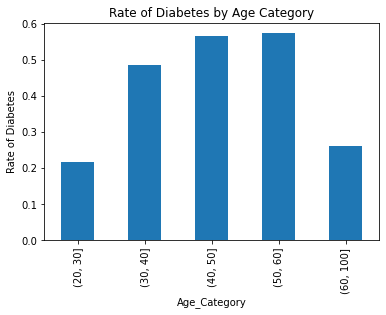

In [863]:
data['Age_Category'] = pd.cut(data['Age'], bins=[20,30,40,50,60,100])

data.groupby('Age_Category')['Outcome'].mean().plot(kind='bar')
plt.title('Rate of Diabetes by Age Category')
plt.ylabel('Rate of Diabetes')
plt.show()

The above bar chart shows that people aged 40-60 yrs are at a higher risk of developing diabetes.

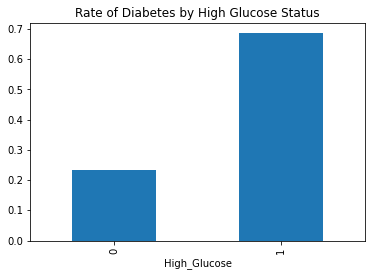

In [864]:
data['High_Glucose'] = (data['Glucose'] >= 140).astype(int)

data.groupby('High_Glucose')['Outcome'].mean().plot(kind='bar')
plt.title('Rate of Diabetes by High Glucose Status')
plt.show()

Patients with high levels of glucose have high diabetes rates compared to others as observed in the bar chart above.

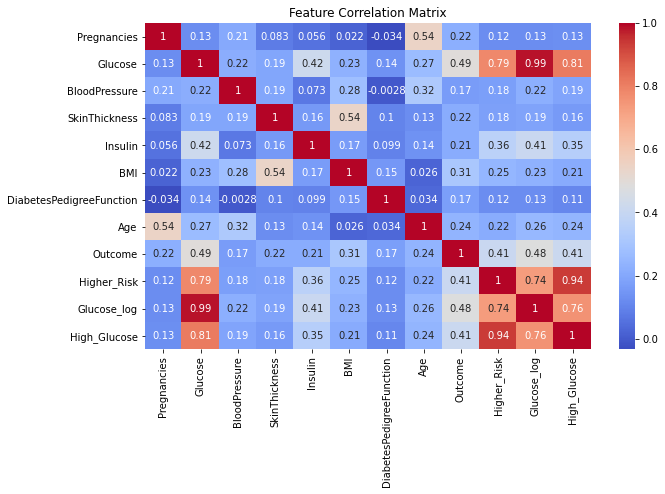

In [865]:
plt.figure(figsize=(10,6))
sns.heatmap(data.corr(), annot=True, cmap='coolwarm')
plt.title('Feature Correlation Matrix')
plt.show()

Glucose is strongly correlated with diabetes outcome.